<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/Binary_Classification_Airoplane_vs_Cars_(_CNN_)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abtabm/multiclassimagedatasetairplanecar")

print("Path to dataset files:", path)

100%|██████████| 333M/333M [00:16<00:00, 21.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abtabm/multiclassimagedatasetairplanecar/versions/2


In [2]:
import os

# List the contents of the downloaded dataset directory
print(os.listdir(path))

['Dataset']


In [3]:

dataset_dir = os.path.join(path, 'Dataset')
print(os.listdir(dataset_dir))

['train', 'test']


In [4]:
train_dir = os.path.join(dataset_dir, 'train')
print("Contents of train directory:", os.listdir(train_dir))

Contents of train directory: ['ship', 'airplanes', 'cars']


In [5]:
import tensorflow as tf

test_dir = os.path.join(dataset_dir, 'test')
print("Contents of test directory:", os.listdir(test_dir))

Contents of test directory: ['airplanes', 'cars', 'ships']


In [6]:

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

CLASS_NAMES = ['airplanes', 'cars']

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    class_names=CLASS_NAMES,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    class_names=CLASS_NAMES,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nTraining dataset class names:", train_ds.class_names)
print("Validation dataset class names:", val_ds.class_names)


for images, labels in train_ds.take(1):
    print(f"\nShape of image batch: {images.shape}")
    print(f"Shape of label batch: {labels.shape}")
    print(f"Sample labels: {labels.numpy().flatten()}")

Found 2000 files belonging to 2 classes.
Found 382 files belonging to 2 classes.

Training dataset class names: ['airplanes', 'cars']
Validation dataset class names: ['airplanes', 'cars']

Shape of image batch: (32, 224, 224, 3)
Shape of label batch: (32, 1)
Sample labels: [0. 0. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0.
 0. 0. 1. 1. 0. 1. 1. 1.]


In [7]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

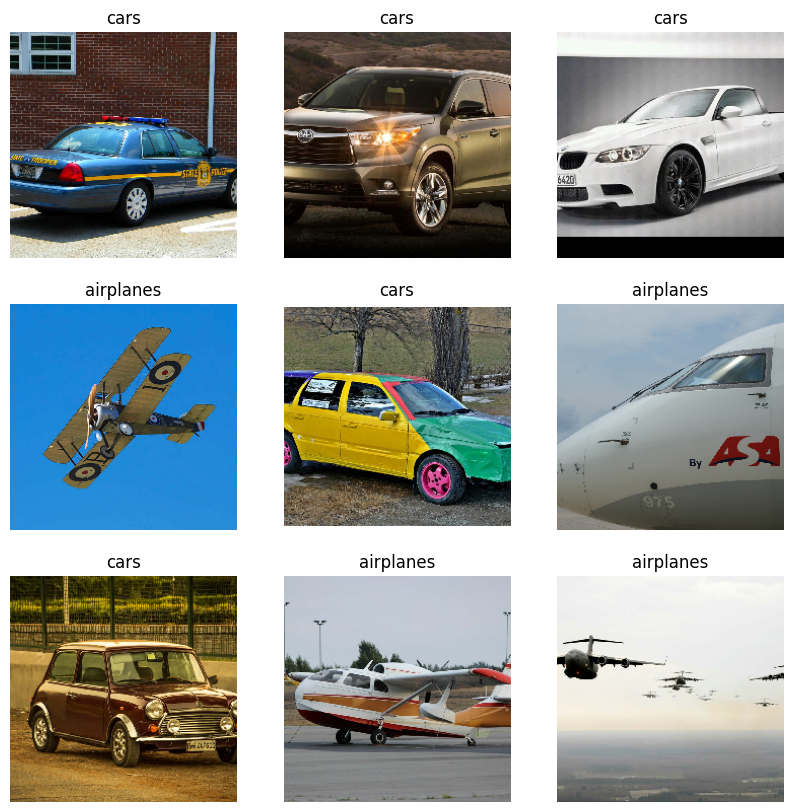

In [8]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        class_idx = int(labels[i])
        plt.title(CLASS_NAMES[class_idx])
        plt.axis("off")

In [9]:
# View the first 5 images and their assigned labels
for images, labels in train_ds.take(1):
    for i in range(5):
        print(f"Image {i} has label: {labels[i].numpy()} -> {CLASS_NAMES[int(labels[i])]}")

Image 0 has label: [1.] -> cars
Image 1 has label: [1.] -> cars
Image 2 has label: [1.] -> cars
Image 3 has label: [1.] -> cars
Image 4 has label: [0.] -> airplanes


**Model Training**

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np


In [ ]:
def build_model(input_Shape):
  model = Sequential()



  model.add(layers.Rescaling(1./255, input_shape=input_Shape))


  # CNN Part
  model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape= input_Shape))
  model.add(layers.MaxPool2D((2,2))) # Half the size


  model.add(layers.Conv2D(64, (3, 3), activation='relu'))
  model.add(layers.MaxPool2D((2,2)))

  # ANN part

  model.add(layers.Flatten())
  model.add(layers.Dense(64, activation='relu'))
  model.add(layers.Dense(1, activation='sigmoid'))

  model.compile(
      optimizer='adam',
      loss = 'binary_crossentropy',
      metrics=['accuracy']
  )

  print(model.summary())

  return model

In [ ]:
model = build_model((224,224,3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history = model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds
)


Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.8160 - loss: 0.6055 - val_accuracy: 0.9188 - val_loss: 0.2366
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.9240 - loss: 0.1844 - val_accuracy: 0.9215 - val_loss: 0.2472
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.9650 - loss: 0.1027 - val_accuracy: 0.9110 - val_loss: 0.2957
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.9855 - loss: 0.0535 - val_accuracy: 0.8927 - val_loss: 0.3930
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - accuracy: 0.9955 - loss: 0.0187 - val_accuracy: 0.9031 - val_loss: 0.3516


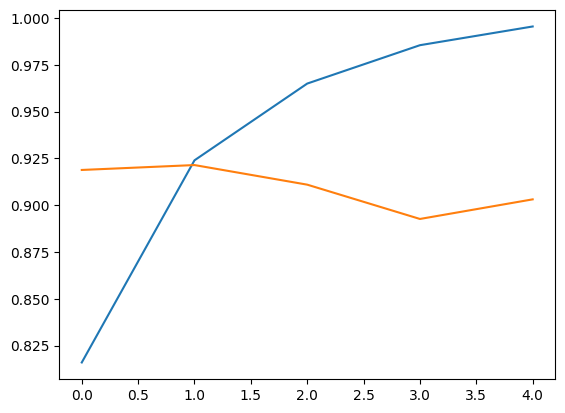

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

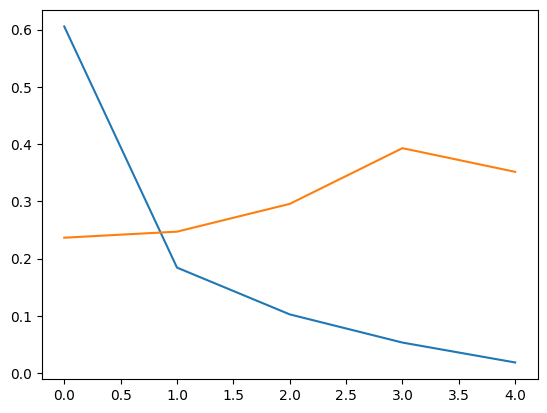

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

the model overfits after 3rd iteration.

**Reducing Overfitting**

Step 1 should be to reduce complexity of the model. As this is the win win situation. By reducing complexity we will have:
1. less computation
2. less time required for training.

In [18]:
def build_optimized_model(input_Shape):

  model = Sequential()

  # Scaling

  model.add(layers.Rescaling(1./255, input_shape=input_Shape))

  # CNN Part

  model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape= input_Shape))
  model.add(layers.MaxPool2D((2,2))) # Half the size


  model.add(layers.Conv2D(64, (3, 3), activation='relu'))
  model.add(layers.MaxPool2D((2,2)))

  # ANN part

  model.add(layers.Flatten())
  model.add(layers.Dense(64, activation='relu'))
  model.add(layers.Dropout(0.5)) # Reduce complexity
  model.add(layers.Dense(1, activation='sigmoid'))

  model.compile(
      optimizer='adam',
      loss = 'binary_crossentropy',
      metrics=['accuracy']
  )

  print(model.summary())

  return model

In [19]:
new_model = build_optimized_model((224,224,3))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

None


In [20]:
history = new_model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8355 - loss: 0.5251 - val_accuracy: 0.9031 - val_loss: 0.2388
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.9170 - loss: 0.2444 - val_accuracy: 0.8534 - val_loss: 0.3096
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.9290 - loss: 0.1947 - val_accuracy: 0.9031 - val_loss: 0.2091
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9485 - loss: 0.1457 - val_accuracy: 0.9293 - val_loss: 0.2086
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9610 - loss: 0.1212 - val_accuracy: 0.9241 - val_loss: 0.2595


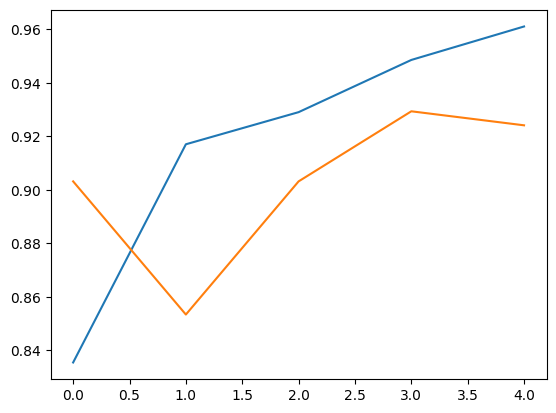

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

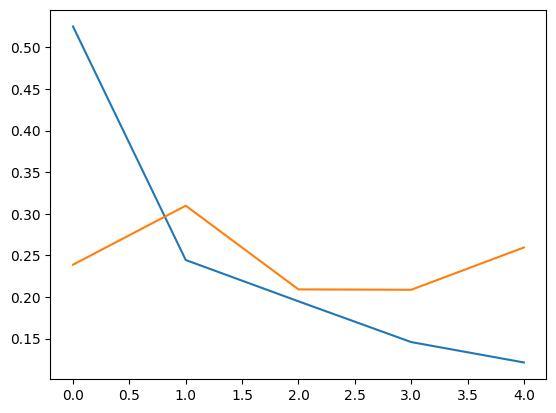

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

The validation accuracy of 92% is solid. And by doing so we shrinked the difference to 3%.

Step 2 Since deep learning Requires extereme data 10000 > images. We will do Data augmentation.


In [26]:

def build_optimized1_model(input_shape):

    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])


    model = keras.Sequential([
        layers.Rescaling(1./255, input_shape=input_shape),

        # CNN layers
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPool2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPool2D((2, 2)),

        # ANN layers
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.summary()
    return model


In [27]:
new_model1= build_optimized1_model((224,224,3))

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history1 = new_model1.fit(
  train_ds,
  epochs=5,
  validation_data=val_ds
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8165 - loss: 0.5346 - val_accuracy: 0.8874 - val_loss: 0.2614
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9120 - loss: 0.2451 - val_accuracy: 0.7906 - val_loss: 0.4528
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.9145 - loss: 0.2181 - val_accuracy: 0.8482 - val_loss: 0.4315
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9475 - loss: 0.1358 - val_accuracy: 0.9110 - val_loss: 0.2716
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.9695 - loss: 0.0860 - val_accuracy: 0.8927 - val_loss: 0.3641


Adding Dropout doesn't worked very well!

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Get all true labels from the validation set
y_true = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true).flatten()

# 2. Get model predictions (probabilities)
y_pred_probs = new_model.predict(val_ds)

# 3. Convert probabilities to binary (0 or 1)
# Since we used a sigmoid, > 0.5 is Class 1 (Cars), < 0.5 is Class 0 (Airplanes)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 498ms/step


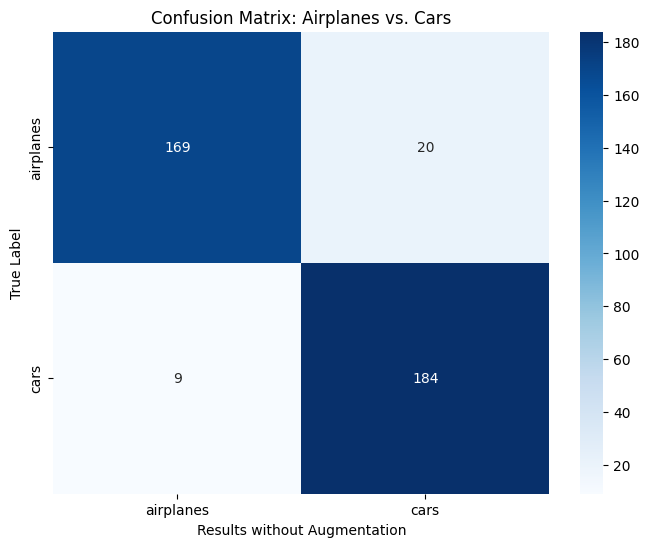

In [32]:

# 4. Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel('Results without Augmentation')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Airplanes vs. Cars')
plt.show()

In [33]:

# 1. Get all true labels from the validation set
y1_true = []
for images, labels in val_ds:
    y1_true.extend(labels.numpy())
y1_true = np.array(y1_true).flatten()

# 2. Get model predictions (probabilities)
y_pred1_probs = new_model1.predict(val_ds)

# 3. Convert probabilities to binary (0 or 1)
# Since we used a sigmoid, > 0.5 is Class 1 (Cars), < 0.5 is Class 0 (Airplanes)
y_pred1 = (y_pred1_probs > 0.5).astype(int).flatten()

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 722ms/step


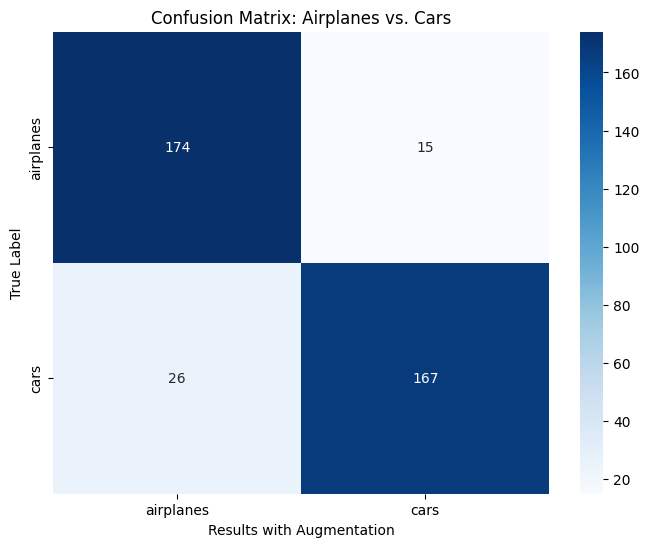

In [35]:
# 4. Create the confusion matrix
cm = confusion_matrix(y1_true, y_pred1)

# 5. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel('Results with Augmentation')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Airplanes vs. Cars')
plt.show()

Augmentation is somehow generating good images for Airplanes and not so good for cars.
In the end it is just fake data!